In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("scores_data.csv")
df.head()

,Batch,User_ID,Score
0,AI_ELITE_7,uid_149,6 / 7
1,AI_ELITE_7,uid_148,6 / 7
2,AI_ELITE_7,uid_147,7 / 7
3,AI_ELITE_7,uid_146,7 / 7
4,AI_ELITE_7,uid_145,4 / 7


In [8]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Batch        149 non-null    object
 1   User_ID      149 non-null    object
 2      Score     149 non-null    object
dtypes: object(3)
memory usage: 3.6+ KB


Index(['Batch ', 'User_ID ', '   Score   '], dtype='object')

In [10]:
df.columns = df.columns.str.strip()
df['score_numeric'] = df['Score'].str.split('/').str[0].astype(int)

In [11]:
df[['Score', 'score_numeric']].head()

,Score,score_numeric
0,6 / 7,6
1,6 / 7,6
2,7 / 7,7
3,7 / 7,7
4,4 / 7,4


In [12]:
df['score_numeric'].describe()
df['Batch'].value_counts()

,count
Batch,
AI_ELITE_7,53
AI_ELITE_6,48
AI_ELITE_4,48


In [13]:
# Batch-wise summary statistics
batch_stats = (df.groupby('Batch')['score_numeric'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max').round(2))
batch_stats

,count,mean,median,std,min,max
Batch,,,,,,
AI_ELITE_4,48,3.79,4.0,1.44,0,7
AI_ELITE_6,48,4.23,4.0,1.64,0,7
AI_ELITE_7,53,5.06,5.0,1.45,2,7


In [20]:
# Percentile analysis
percentiles = (df.groupby('Batch')['score_numeric'].quantile([0.25, 0.5, 0.75, 0.9]).unstack()
.rename(columns={0.25: 'p25',0.5: 'p50_median',0.75: 'p75',0.9: 'p90'}))
percentiles

,p25,p50_median,p75,p90
Batch,,,,
AI_ELITE_4,3.0,4.0,4.25,5.0
AI_ELITE_6,3.0,4.0,5.00,6.3
AI_ELITE_7,4.0,5.0,6.00,7.0


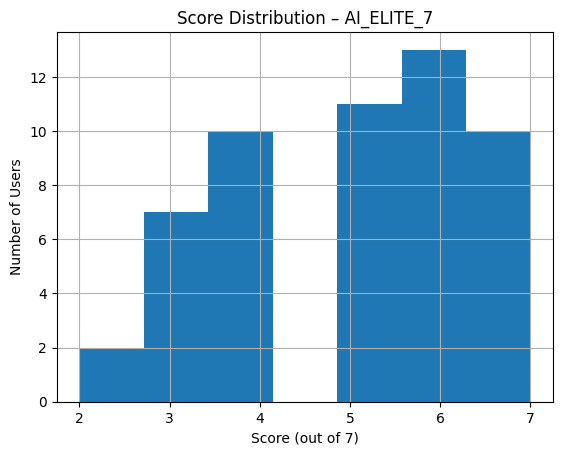

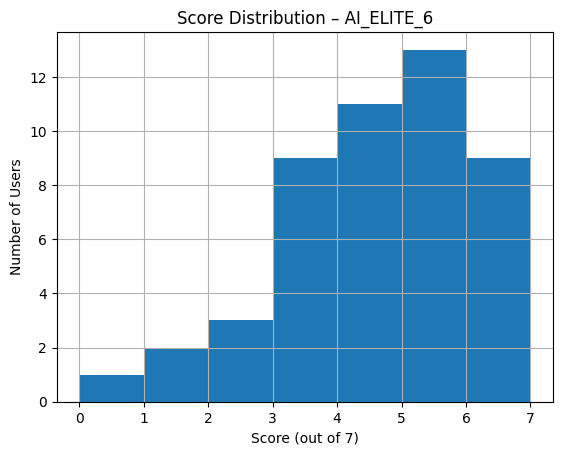

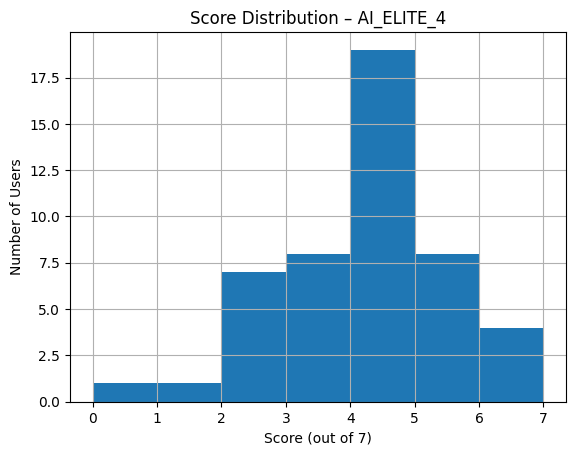

In [15]:
# Distribution visualization
for batch in df['Batch'].unique():
    plt.figure()
    df[df['Batch'] == batch]['score_numeric'].hist(bins=7)
    plt.title(f"Score Distribution – {batch}")
    plt.xlabel("Score (out of 7)")
    plt.ylabel("Number of Users")
    plt.show()

<Figure size 640x480 with 0 Axes>

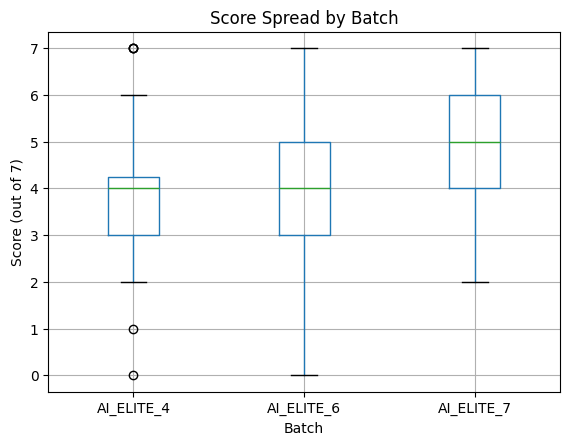

In [16]:
# Boxplot comparison
plt.figure()
df.boxplot(column='score_numeric', by='Batch')
plt.title("Score Spread by Batch")
plt.suptitle("")
plt.xlabel("Batch")
plt.ylabel("Score (out of 7)")
plt.show()

In [17]:
# Identify performance bands
def score_band(score):
    if score >= 6:
        return 'High'
    elif score >= 4:
        return 'Medium'
    else:
        return 'Low'
df['performance_band'] = df['score_numeric'].apply(score_band)

In [18]:
band_distribution = (df.groupby(['Batch', 'performance_band']).size().unstack(fill_value=0))
band_distribution

performance_band,High,Low,Medium
Batch,,,
AI_ELITE_4,4,17,27
AI_ELITE_6,9,15,24
AI_ELITE_7,23,9,21


In [19]:
# Insights
summary = (df.groupby('Batch').agg(
    avg_score=('score_numeric', 'mean'),
    high_pct=('score_numeric', lambda x: (x >= 6).mean() * 100),
    low_pct=('score_numeric', lambda x: (x <= 3).mean() * 100)).round(2))
summary

,avg_score,high_pct,low_pct
Batch,,,
AI_ELITE_4,3.79,8.33,35.42
AI_ELITE_6,4.23,18.75,31.25
AI_ELITE_7,5.06,43.40,16.98
